=== 임베딩 파일 로드 및 군집 개수 최적화 ===
발견된 임베딩 파일 수: 11
- comprehensive_filtered_patient_embeddings_batch_3.json: 26.80 MB
- comprehensive_filtered_patient_embeddings_batch_10.json: 26.41 MB
- comprehensive_filtered_patient_embeddings_batch_11.json: 5.98 MB
- comprehensive_filtered_patient_embeddings_batch_2.json: 26.57 MB
- comprehensive_filtered_patient_embeddings_batch_9.json: 26.89 MB
- comprehensive_filtered_patient_embeddings_batch_5.json: 26.79 MB
- comprehensive_filtered_patient_embeddings_batch_4.json: 26.82 MB
- comprehensive_filtered_patient_embeddings_batch_8.json: 27.04 MB
- comprehensive_filtered_patient_embeddings_batch_7.json: 26.95 MB
- comprehensive_filtered_patient_embeddings_batch_6.json: 26.88 MB
- comprehensive_filtered_patient_embeddings_batch_1.json: 26.08 MB

임베딩 데이터 로드 중...
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehensive_filtered_patient_embeddings_batch_3.json에서 500개 임베딩 로드 완료
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddi

/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  plt.tight_layout()
/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_1648/1605716045.py:102: UserWarn

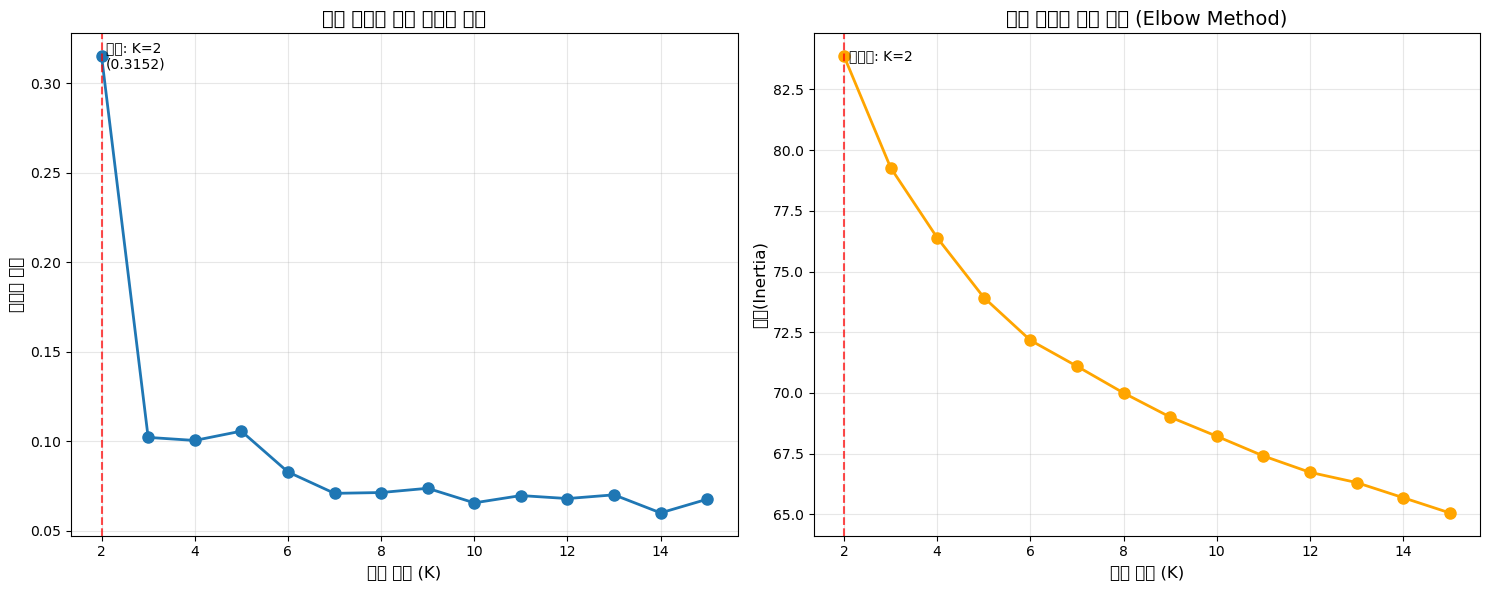


=== 군집 개수 최적화 결과 ===
실루엣 점수 기준 최적 군집 개수: 2 (점수: 0.3152)
엘보우 방법 기준 최적 군집 개수: 2

=== 상세 평가 결과 ===
K	실루엣 점수	관성값
------------------------------
2	0.3152		83.87
3	0.1022		79.28
4	0.1005		76.39
5	0.1057		73.93
6	0.0829		72.17
7	0.0709		71.10
8	0.0714		70.00
9	0.0738		69.01
10	0.0656		68.22
11	0.0697		67.40
12	0.0680		66.73
13	0.0701		66.31
14	0.0600		65.69
15	0.0677		65.06

=== 최종 권장사항 ===
권장 군집 개수: 2 (실루엣 점수와 엘보우 방법 일치)


In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def load_patient_embeddings(embedding_files):
    """저장된 환자 임베딩 파일들을 로드하는 함수"""
    all_embeddings = []
    
    for file_path in embedding_files:
        if not os.path.exists(file_path):
            print(f"경고: {file_path} 파일이 존재하지 않습니다.")
            continue
            
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, list):
                for item in data:
                    if 'patient_id' in item and 'embedding' in item:
                        # 문자열이나 리스트로 저장된 임베딩을 NumPy 배열로 변환
                        if isinstance(item['embedding'], list):
                            item['embedding'] = np.array(item['embedding'])
                
                print(f"{file_path}에서 {len(data)}개 임베딩 로드 완료")
                all_embeddings.extend(data)
            else:
                print(f"경고: {file_path}의 형식이 예상과 다릅니다.")
                
        except Exception as e:
            print(f"{file_path} 로드 중 오류 발생: {e}")
    
    print(f"총 {len(all_embeddings)}개 환자 임베딩 로드 완료")
    return all_embeddings

def optimize_cluster_count(embeddings, max_clusters=10):
    """적절한 군집 개수 결정"""
    # 평가 지표 저장
    silhouette_scores = []
    inertia_values = []
    
    print(f"임베딩 데이터 형태: {embeddings.shape}")
    print(f"K=2부터 K={max_clusters}까지 군집화 성능 평가 중...")
    
    # 다양한 K 값에 대해 군집화 수행
    for k in range(2, max_clusters + 1):
        print(f"K={k} 평가 중...", end=" ")
        
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        
        # 실루엣 점수 계산
        silhouette_avg = silhouette_score(embeddings, labels)
        silhouette_scores.append(silhouette_avg)
        
        # 관성(inertia) 저장
        inertia_values.append(kmeans.inertia_)
        
        print(f"실루엣 점수: {silhouette_avg:.4f}")
    
    # 그래프 시각화
    plt.figure(figsize=(15, 6))
    
    # 실루엣 점수 그래프
    plt.subplot(1, 2, 1)
    plt.plot(range(2, max_clusters + 1), silhouette_scores, 'o-', linewidth=2, markersize=8)
    plt.xlabel('군집 개수 (K)', fontsize=12)
    plt.ylabel('실루엣 점수', fontsize=12)
    plt.title('군집 개수에 따른 실루엣 점수', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 최고 점수 표시
    best_idx = np.argmax(silhouette_scores)
    best_k = best_idx + 2
    plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
    plt.text(best_k + 0.1, silhouette_scores[best_idx], 
             f'최고: K={best_k}\n({silhouette_scores[best_idx]:.4f})', 
             fontsize=10, verticalalignment='center')
    
    # 엘보우 그래프
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_clusters + 1), inertia_values, 'o-', linewidth=2, markersize=8, color='orange')
    plt.xlabel('군집 개수 (K)', fontsize=12)
    plt.ylabel('관성(Inertia)', fontsize=12)
    plt.title('군집 개수에 따른 관성 (Elbow Method)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 엘보우 포인트 계산 및 표시
    inertia_changes = np.diff(inertia_values)
    normalized_changes = np.abs(inertia_changes / inertia_values[:-1])
    elbow_idx = np.argmax(normalized_changes)
    elbow_k = elbow_idx + 2
    plt.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7)
    plt.text(elbow_k + 0.1, inertia_values[elbow_idx], 
             f'엘보우: K={elbow_k}', 
             fontsize=10, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    # 최적의 K 제안
    best_silhouette_idx = np.argmax(silhouette_scores)
    best_k_silhouette = best_silhouette_idx + 2  # 인덱스 보정
    
    # 엘보우 방법 결과
    best_k_elbow = elbow_k
    
    print(f"\n=== 군집 개수 최적화 결과 ===")
    print(f"실루엣 점수 기준 최적 군집 개수: {best_k_silhouette} (점수: {silhouette_scores[best_silhouette_idx]:.4f})")
    print(f"엘보우 방법 기준 최적 군집 개수: {best_k_elbow}")
    
    # 상세 결과 테이블
    print(f"\n=== 상세 평가 결과 ===")
    print("K\t실루엣 점수\t관성값")
    print("-" * 30)
    for i, k in enumerate(range(2, max_clusters + 1)):
        print(f"{k}\t{silhouette_scores[i]:.4f}\t\t{inertia_values[i]:.2f}")
    
    return best_k_silhouette, best_k_elbow, silhouette_scores, inertia_values

def main():
    """메인 실행 함수"""
    # 임베딩 파일 경로 설정
    embedding_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
    
    print("=== 임베딩 파일 로드 및 군집 개수 최적화 ===")
    
    # 1. 임베딩 파일 찾기
    if not os.path.exists(embedding_dir):
        print(f"오류: 임베딩 디렉토리가 존재하지 않습니다: {embedding_dir}")
        return
    
    # 모든 JSON 파일 찾기
    embedding_files = glob.glob(os.path.join(embedding_dir, '*.json'))
    
    if not embedding_files:
        print(f"오류: {embedding_dir}에서 JSON 파일을 찾을 수 없습니다.")
        return
    
    print(f"발견된 임베딩 파일 수: {len(embedding_files)}")
    
    # 파일 크기 정보 출력
    for file in embedding_files:
        file_size = os.path.getsize(file) / (1024*1024)  # MB 단위
        print(f"- {os.path.basename(file)}: {file_size:.2f} MB")
    
    # 2. 임베딩 데이터 로드
    print("\n임베딩 데이터 로드 중...")
    patient_embeddings = load_patient_embeddings(embedding_files)
    
    if not patient_embeddings:
        print("오류: 유효한 임베딩 데이터를 로드할 수 없습니다.")
        return
    
    # 3. 임베딩 벡터 추출
    print("임베딩 벡터 추출 중...")
    embeddings_array = []
    
    for item in patient_embeddings:
        if 'embedding' in item:
            embedding = item['embedding']
            if isinstance(embedding, np.ndarray):
                embeddings_array.append(embedding)
            elif isinstance(embedding, list):
                embeddings_array.append(np.array(embedding))
            else:
                print(f"경고: 환자 {item.get('patient_id', 'unknown')}의 임베딩 형식이 올바르지 않습니다.")
    
    if not embeddings_array:
        print("오류: 유효한 임베딩 벡터를 찾을 수 없습니다.")
        return
    
    # NumPy 배열로 변환
    embeddings_matrix = np.array(embeddings_array)
    print(f"최종 임베딩 매트릭스 형태: {embeddings_matrix.shape}")
    
    # 4. 군집 개수 최적화 실행
    print("\n군집 개수 최적화 시작...")
    
    # 데이터 크기에 따라 최대 군집 수 조정
    max_clusters = min(15, len(embeddings_matrix) // 3)  # 각 군집에 최소 3개 샘플
    max_clusters = max(max_clusters, 3)  # 최소 3개 군집까지는 테스트
    
    print(f"최대 군집 수: {max_clusters}")
    
    try:
        best_k_silhouette, best_k_elbow, silhouette_scores, inertia_values = optimize_cluster_count(
            embeddings_matrix, max_clusters=max_clusters
        )
        
        # 5. 결과 요약
        print(f"\n=== 최종 권장사항 ===")
        if best_k_silhouette == best_k_elbow:
            print(f"권장 군집 개수: {best_k_silhouette} (실루엣 점수와 엘보우 방법 일치)")
        else:
            print(f"실루엣 점수 기준: {best_k_silhouette}개 군집")
            print(f"엘보우 방법 기준: {best_k_elbow}개 군집")
            print(f"일반적으로 실루엣 점수를 우선 고려하는 것을 권장합니다.")
        
        return best_k_silhouette, best_k_elbow, embeddings_matrix
        
    except Exception as e:
        print(f"군집화 최적화 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()
        return None, None, embeddings_matrix

if __name__ == "__main__":
    result = main()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, 
    SpectralClustering, OPTICS
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, 
    calinski_harabasz_score, adjusted_rand_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def comprehensive_clustering_analysis(embeddings_matrix, max_clusters=8):
    """
    다양한 클러스터링 방법들을 종합적으로 비교 분석
    
    Parameters:
    -----------
    embeddings_matrix : numpy.ndarray
        환자 임베딩 매트릭스
    max_clusters : int
        최대 클러스터 수 (기본값: 8)
    
    Returns:
    --------
    dict : 각 방법별 결과와 평가지표
    """
    
    print(f"=== 종합적 클러스터링 방법 비교 분석 ===")
    print(f"데이터 크기: {embeddings_matrix.shape}")
    print(f"최대 클러스터 수: {max_clusters}")
    
    # 데이터 전처리
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    # PCA로 차원 축소 (시각화용)
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings_scaled)
    
    # 결과 저장용 딕셔너리
    results = {
        'methods': {},
        'comparison_table': [],
        'best_method': None,
        'embeddings_2d': embeddings_2d,
        'embeddings_scaled': embeddings_scaled
    }
    
    print("\n" + "="*60)
    
    # 1. K-Means Clustering
    print("1. K-Means Clustering")
    print("-" * 30)
    
    kmeans_results = analyze_kmeans(embeddings_scaled, max_clusters)
    results['methods']['K-Means'] = kmeans_results
    
    # 2. Hierarchical Clustering (Agglomerative)
    print("\n2. Hierarchical Clustering (Agglomerative)")
    print("-" * 45)
    
    hierarchical_results = analyze_hierarchical(embeddings_scaled, max_clusters)
    results['methods']['Hierarchical'] = hierarchical_results
    
    # 3. DBSCAN
    print("\n3. DBSCAN (Density-Based)")
    print("-" * 30)
    
    dbscan_results = analyze_dbscan(embeddings_scaled)
    results['methods']['DBSCAN'] = dbscan_results
    
    # 4. Gaussian Mixture Model
    print("\n4. Gaussian Mixture Model")
    print("-" * 30)
    
    gmm_results = analyze_gmm(embeddings_scaled, max_clusters)
    results['methods']['GMM'] = gmm_results
    
    # 5. Spectral Clustering
    print("\n5. Spectral Clustering")
    print("-" * 25)
    
    spectral_results = analyze_spectral(embeddings_scaled, max_clusters)
    results['methods']['Spectral'] = spectral_results
    
    # 6. OPTICS
    print("\n6. OPTICS")
    print("-" * 15)
    
    optics_results = analyze_optics(embeddings_scaled)
    results['methods']['OPTICS'] = optics_results
    
    # 결과 비교 및 최적 방법 선택
    print("\n" + "="*60)
    print("방법별 성능 비교 및 최적화")
    print("="*60)
    
    comparison_results = compare_methods(results['methods'])
    results['comparison_table'] = comparison_results['table']
    results['best_method'] = comparison_results['best_method']
    
    # 시각화
    visualize_clustering_results(results)
    
    return results

def analyze_kmeans(embeddings_scaled, max_clusters):
    """K-Means 클러스터링 분석"""
    results = {'scores': [], 'best_k': None, 'best_labels': None, 'best_model': None}
    
    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings_scaled)
        
        # 평가지표 계산
        sil_score = silhouette_score(embeddings_scaled, labels)
        db_score = davies_bouldin_score(embeddings_scaled, labels)
        ch_score = calinski_harabasz_score(embeddings_scaled, labels)
        
        results['scores'].append({
            'k': k,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'inertia': kmeans.inertia_,
            'labels': labels.copy(),
            'model': kmeans
        })
        
        print(f"K={k}: Silhouette={sil_score:.4f}, DB={db_score:.4f}, CH={ch_score:.2f}")
    
    # 최적 K 선택 (실루엣 점수 기준)
    best_idx = max(range(len(results['scores'])), key=lambda i: results['scores'][i]['silhouette'])
    results['best_k'] = results['scores'][best_idx]['k']
    results['best_labels'] = results['scores'][best_idx]['labels']
    results['best_model'] = results['scores'][best_idx]['model']
    
    print(f"최적 K: {results['best_k']} (Silhouette: {results['scores'][best_idx]['silhouette']:.4f})")
    
    return results

def analyze_hierarchical(embeddings_scaled, max_clusters):
    """계층적 클러스터링 분석"""
    results = {'scores': [], 'best_k': None, 'best_labels': None, 'linkage_matrix': None}
    
    # Linkage 계산
    linkage_matrix = linkage(embeddings_scaled, method='ward')
    results['linkage_matrix'] = linkage_matrix
    
    for k in range(2, max_clusters + 1):
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hierarchical.fit_predict(embeddings_scaled)
        
        # 평가지표 계산
        sil_score = silhouette_score(embeddings_scaled, labels)
        db_score = davies_bouldin_score(embeddings_scaled, labels)
        ch_score = calinski_harabasz_score(embeddings_scaled, labels)
        
        results['scores'].append({
            'k': k,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'labels': labels.copy(),
            'model': hierarchical
        })
        
        print(f"K={k}: Silhouette={sil_score:.4f}, DB={db_score:.4f}, CH={ch_score:.2f}")
    
    # 최적 K 선택
    best_idx = max(range(len(results['scores'])), key=lambda i: results['scores'][i]['silhouette'])
    results['best_k'] = results['scores'][best_idx]['k']
    results['best_labels'] = results['scores'][best_idx]['labels']
    
    print(f"최적 K: {results['best_k']} (Silhouette: {results['scores'][best_idx]['silhouette']:.4f})")
    
    return results

def analyze_dbscan(embeddings_scaled):
    """DBSCAN 클러스터링 분석"""
    results = {'best_params': None, 'best_labels': None, 'best_score': -1}
    
    # 하이퍼파라미터 그리드 서치
    eps_values = np.arange(0.1, 2.0, 0.1)
    min_samples_values = [3, 5, 10, 15, 20]
    
    print("하이퍼파라미터 최적화 중...")
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(embeddings_scaled)
            
            # 노이즈 포인트(-1) 제외하고 평가
            if len(set(labels)) > 1 and -1 not in labels:
                try:
                    sil_score = silhouette_score(embeddings_scaled, labels)
                    if sil_score > results['best_score']:
                        results['best_score'] = sil_score
                        results['best_params'] = {'eps': eps, 'min_samples': min_samples}
                        results['best_labels'] = labels.copy()
                except:
                    continue
    
    if results['best_params']:
        print(f"최적 파라미터: eps={results['best_params']['eps']:.2f}, "
              f"min_samples={results['best_params']['min_samples']}")
        print(f"Silhouette Score: {results['best_score']:.4f}")
        print(f"클러스터 수: {len(set(results['best_labels']))}")
        print(f"노이즈 포인트: {sum(results['best_labels'] == -1)}개")
    else:
        print("적절한 클러스터를 찾지 못했습니다.")
        results['best_labels'] = np.zeros(len(embeddings_scaled))  # 기본값
    
    return results

def analyze_gmm(embeddings_scaled, max_clusters):
    """Gaussian Mixture Model 분석"""
    results = {'scores': [], 'best_k': None, 'best_labels': None, 'best_model': None}
    
    for k in range(2, max_clusters + 1):
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels = gmm.fit_predict(embeddings_scaled)
        
        # 평가지표 계산
        sil_score = silhouette_score(embeddings_scaled, labels)
        db_score = davies_bouldin_score(embeddings_scaled, labels)
        ch_score = calinski_harabasz_score(embeddings_scaled, labels)
        bic_score = gmm.bic(embeddings_scaled)
        aic_score = gmm.aic(embeddings_scaled)
        
        results['scores'].append({
            'k': k,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'bic': bic_score,
            'aic': aic_score,
            'labels': labels.copy(),
            'model': gmm
        })
        
        print(f"K={k}: Silhouette={sil_score:.4f}, BIC={bic_score:.2f}, AIC={aic_score:.2f}")
    
    # 최적 K 선택 (실루엣 점수 기준)
    best_idx = max(range(len(results['scores'])), key=lambda i: results['scores'][i]['silhouette'])
    results['best_k'] = results['scores'][best_idx]['k']
    results['best_labels'] = results['scores'][best_idx]['labels']
    results['best_model'] = results['scores'][best_idx]['model']
    
    print(f"최적 K: {results['best_k']} (Silhouette: {results['scores'][best_idx]['silhouette']:.4f})")
    
    return results

def analyze_spectral(embeddings_scaled, max_clusters):
    """Spectral Clustering 분석"""
    results = {'scores': [], 'best_k': None, 'best_labels': None}
    
    for k in range(2, max_clusters + 1):
        spectral = SpectralClustering(n_clusters=k, random_state=42, affinity='rbf')
        labels = spectral.fit_predict(embeddings_scaled)
        
        # 평가지표 계산
        sil_score = silhouette_score(embeddings_scaled, labels)
        db_score = davies_bouldin_score(embeddings_scaled, labels)
        ch_score = calinski_harabasz_score(embeddings_scaled, labels)
        
        results['scores'].append({
            'k': k,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'labels': labels.copy()
        })
        
        print(f"K={k}: Silhouette={sil_score:.4f}, DB={db_score:.4f}, CH={ch_score:.2f}")
    
    # 최적 K 선택
    best_idx = max(range(len(results['scores'])), key=lambda i: results['scores'][i]['silhouette'])
    results['best_k'] = results['scores'][best_idx]['k']
    results['best_labels'] = results['scores'][best_idx]['labels']
    
    print(f"최적 K: {results['best_k']} (Silhouette: {results['scores'][best_idx]['silhouette']:.4f})")
    
    return results

def analyze_optics(embeddings_scaled):
    """OPTICS 클러스터링 분석"""
    results = {'best_params': None, 'best_labels': None, 'best_score': -1}
    
    # 하이퍼파라미터 그리드 서치
    min_samples_values = [5, 10, 15, 20, 25]
    
    print("하이퍼파라미터 최적화 중...")
    
    for min_samples in min_samples_values:
        optics = OPTICS(min_samples=min_samples)
        labels = optics.fit_predict(embeddings_scaled)
        
        # 노이즈 포인트(-1) 제외하고 평가
        if len(set(labels)) > 1 and -1 not in labels:
            try:
                sil_score = silhouette_score(embeddings_scaled, labels)
                if sil_score > results['best_score']:
                    results['best_score'] = sil_score
                    results['best_params'] = {'min_samples': min_samples}
                    results['best_labels'] = labels.copy()
            except:
                continue
    
    if results['best_params']:
        print(f"최적 파라미터: min_samples={results['best_params']['min_samples']}")
        print(f"Silhouette Score: {results['best_score']:.4f}")
        print(f"클러스터 수: {len(set(results['best_labels']))}")
        print(f"노이즈 포인트: {sum(results['best_labels'] == -1)}개")
    else:
        print("적절한 클러스터를 찾지 못했습니다.")
        results['best_labels'] = np.zeros(len(embeddings_scaled))  # 기본값
    
    return results

def compare_methods(methods_results):
    """클러스터링 방법들 비교"""
    comparison_table = []
    
    for method_name, result in methods_results.items():
        if method_name in ['K-Means', 'Hierarchical', 'GMM', 'Spectral']:
            # 클러스터 수를 지정하는 방법들
            best_score = max(result['scores'], key=lambda x: x['silhouette'])
            comparison_table.append({
                'Method': method_name,
                'Best_K': best_score['k'],
                'Silhouette': best_score['silhouette'],
                'Davies_Bouldin': best_score['davies_bouldin'],
                'Calinski_Harabasz': best_score['calinski_harabasz']
            })
        elif method_name in ['DBSCAN', 'OPTICS']:
            # 자동으로 클러스터 수를 결정하는 방법들
            if result['best_score'] > -1:
                n_clusters = len(set(result['best_labels']))
                comparison_table.append({
                    'Method': method_name,
                    'Best_K': n_clusters,
                    'Silhouette': result['best_score'],
                    'Davies_Bouldin': 'N/A',
                    'Calinski_Harabasz': 'N/A'
                })
    
    # 결과 테이블 출력
    df_comparison = pd.DataFrame(comparison_table)
    print("\n=== 방법별 성능 비교 ===")
    print(df_comparison.to_string(index=False, float_format='%.4f'))
    
    # 최적 방법 선택 (실루엣 점수 기준)
    best_method_idx = df_comparison['Silhouette'].idxmax()
    best_method = df_comparison.loc[best_method_idx, 'Method']
    
    print(f"\n최적 클러스터링 방법: {best_method}")
    print(f"최적 클러스터 수: {df_comparison.loc[best_method_idx, 'Best_K']}")
    print(f"실루엣 점수: {df_comparison.loc[best_method_idx, 'Silhouette']:.4f}")
    
    return {'table': comparison_table, 'best_method': best_method}

def visualize_clustering_results(results):
    """클러스터링 결과 시각화"""
    methods = list(results['methods'].keys())
    n_methods = len(methods)
    
    # 서브플롯 설정
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = plt.cm.Set3(np.linspace(0, 1, 12))
    
    for i, method_name in enumerate(methods):
        ax = axes[i]
        result = results['methods'][method_name]
        
        if method_name in ['K-Means', 'Hierarchical', 'GMM', 'Spectral']:
            labels = result['best_labels']
        elif method_name in ['DBSCAN', 'OPTICS']:
            labels = result['best_labels']
        
        # 클러스터별 색상 지정
        unique_labels = np.unique(labels)
        
        for label in unique_labels:
            if label == -1:  # 노이즈 포인트
                color = 'black'
                marker = 'x'
                alpha = 0.5
            else:
                color = colors[label % len(colors)]
                marker = 'o'
                alpha = 0.7
            
            mask = labels == label
            ax.scatter(results['embeddings_2d'][mask, 0], 
                      results['embeddings_2d'][mask, 1],
                      c=[color], marker=marker, alpha=alpha, s=50)
        
        ax.set_title(f'{method_name}\n(K={len(unique_labels)})', fontsize=12)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)
    
    # 빈 서브플롯 제거
    for i in range(n_methods, len(axes)):
        fig.delaxes(axes[i])
    
    plt.suptitle('클러스터링 방법별 결과 비교 (PCA 2D 투영)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 성능 비교 막대 그래프
    plt.figure(figsize=(12, 6))
    
    methods_with_scores = []
    silhouette_scores = []
    
    for entry in results['comparison_table']:
        methods_with_scores.append(entry['Method'])
        silhouette_scores.append(entry['Silhouette'])
    
    bars = plt.bar(methods_with_scores, silhouette_scores, 
                   color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'][:len(methods_with_scores)])
    
    plt.xlabel('클러스터링 방법')
    plt.ylabel('실루엣 점수')
    plt.title('클러스터링 방법별 성능 비교')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # 최고 성능 강조
    max_idx = np.argmax(silhouette_scores)
    bars[max_idx].set_color('red')
    bars[max_idx].set_alpha(0.8)
    
    # 점수 표시
    for i, score in enumerate(silhouette_scores):
        plt.text(i, score + 0.005, f'{score:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# 메인 실행 함수
def main_clustering_comparison(embeddings_matrix):
    """
    메인 클러스터링 비교 분석 실행
    
    Parameters:
    -----------
    embeddings_matrix : numpy.ndarray
        환자 임베딩 매트릭스
    """
    
    print("다양한 클러스터링 방법 종합 비교 시작...")
    
    # 데이터 크기에 따라 최대 클러스터 수 조정
    max_clusters = min(8, len(embeddings_matrix) // 5)
    max_clusters = max(max_clusters, 3)
    
    # 종합 분석 실행
    results = comprehensive_clustering_analysis(embeddings_matrix, max_clusters)
    
    # 추가 분석: 안정성 검증
    print("\n" + "="*60)
    print("클러스터링 안정성 검증")
    print("="*60)
    
    stability_results = validate_clustering_stability(embeddings_matrix, results['best_method'])
    
    print(f"\n=== 최종 권장사항 ===")
    print(f"최적 클러스터링 방법: {results['best_method']}")
    print(f"안정성 점수: {stability_results['mean_stability']:.4f} ± {stability_results['std_stability']:.4f}")
    
    if stability_results['mean_stability'] > 0.7:
        print("높은 안정성 - 신뢰할 수 있는 결과")
    elif stability_results['mean_stability'] > 0.5:
        print("중간 안정성 - 추가 검증 권장")
    else:
        print("낮은 안정성 - 결과 해석 시 주의 필요")
    
    return results

def validate_clustering_stability(embeddings_matrix, best_method, n_iterations=10):
    """클러스터링 안정성 검증 (Bootstrap 방법)"""
    from sklearn.metrics import adjusted_rand_score
    
    stability_scores = []
    
    print(f"{best_method} 방법의 안정성 검증 중...")
    
    # 기준 클러스터링 결과
    if best_method == 'K-Means':
        base_model = KMeans(n_clusters=2, random_state=42)
    elif best_method == 'Hierarchical':
        base_model = AgglomerativeClustering(n_clusters=2)
    elif best_method == 'GMM':
        base_model = GaussianMixture(n_components=2, random_state=42)
    elif best_method == 'Spectral':
        base_model = SpectralClustering(n_clusters=2, random_state=42)
    
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    base_labels = base_model.fit_predict(embeddings_scaled)
    
    # Bootstrap 샘플링으로 안정성 측정
    for i in range(n_iterations):
        # 부트스트랩 샘플링
        n_samples = len(embeddings_matrix)
        bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)
        bootstrap_data = embeddings_scaled[bootstrap_indices]
        
        # 동일 방법으로 클러스터링
        if best_method == 'K-Means':
            model = KMeans(n_clusters=2, random_state=i)
        elif best_method == 'Hierarchical':
            model = AgglomerativeClustering(n_clusters=2)
        elif best_method == 'GMM':
            model = GaussianMixture(n_components=2, random_state=i)
        elif best_method == 'Spectral':
            model = SpectralClustering(n_clusters=2, random_state=i)
        
        bootstrap_labels = model.fit_predict(bootstrap_data)
        
        # 원본 인덱스에 대한 레이블 매핑
        original_bootstrap_labels = bootstrap_labels
        original_base_labels = base_labels[bootstrap_indices]
        
        # ARI로 안정성 측정
        ari_score = adjusted_rand_score(original_base_labels, original_bootstrap_labels)
        stability_scores.append(ari_score)
    
    mean_stability = np.mean(stability_scores)
    std_stability = np.std(stability_scores)
    
    print(f"안정성 점수: {mean_stability:.4f} ± {std_stability:.4f}")
    
    return {
        'mean_stability': mean_stability,
        'std_stability': std_stability,
        'all_scores': stability_scores
    }

In [3]:
# 노트북에서 바로 실행할 수 있는 코드
import os
import glob
import json
import numpy as np

# 1. 기존 임베딩 데이터 로드
def load_embeddings_for_comparison():
    """기존 임베딩 데이터를 로드하여 클러스터링 비교에 사용"""
    embedding_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
    embedding_files = glob.glob(os.path.join(embedding_dir, '*.json'))
    
    if not embedding_files:
        print("임베딩 파일을 찾을 수 없습니다.")
        return None
    
    all_embeddings = []
    for file_path in embedding_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, list):
                for item in data:
                    if 'embedding' in item and 'patient_id' in item:
                        embedding = np.array(item['embedding']) if isinstance(item['embedding'], list) else item['embedding']
                        all_embeddings.append(embedding)
        except Exception as e:
            print(f"파일 로드 오류: {file_path} - {e}")
    
    if all_embeddings:
        embeddings_matrix = np.array(all_embeddings)
        print(f"임베딩 매트릭스 로드 완료: {embeddings_matrix.shape}")
        return embeddings_matrix
    else:
        print("유효한 임베딩 데이터를 찾을 수 없습니다.")
        return None

# 2. 클러스터링 비교 실행
def run_comparison():
    """클러스터링 방법 비교 실행"""
    
    # 임베딩 데이터 로드
    embeddings_matrix = load_embeddings_for_comparison()
    
    if embeddings_matrix is None:
        return
    
    print("="*60)
    print("다양한 클러스터링 방법 종합 비교 분석 시작")
    print("="*60)
    
    # 위에서 정의한 함수가 있다면 실행
    try:
        results = main_clustering_comparison(embeddings_matrix)
        return results
    except NameError:
        print("클러스터링 비교 함수들이 정의되지 않았습니다.")
        print("위의 전체 코드를 먼저 실행해주세요.")
        return None

# 3. 간단한 비교 (함수가 정의되지 않은 경우)
def simple_comparison(embeddings_matrix):
    """간단한 클러스터링 방법 비교"""
    from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
    from sklearn.mixture import GaussianMixture
    from sklearn.metrics import silhouette_score
    from sklearn.preprocessing import StandardScaler
    import matplotlib.pyplot as plt
    
    # 데이터 전처리
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    methods = {}
    
    # 1. K-Means (K=2)
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans_labels = kmeans.fit_predict(embeddings_scaled)
    methods['K-Means'] = {
        'labels': kmeans_labels,
        'silhouette': silhouette_score(embeddings_scaled, kmeans_labels)
    }
    
    # 2. Hierarchical (K=2)
    hierarchical = AgglomerativeClustering(n_clusters=2)
    hierarchical_labels = hierarchical.fit_predict(embeddings_scaled)
    methods['Hierarchical'] = {
        'labels': hierarchical_labels,
        'silhouette': silhouette_score(embeddings_scaled, hierarchical_labels)
    }
    
    # 3. GMM (K=2)
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm_labels = gmm.fit_predict(embeddings_scaled)
    methods['GMM'] = {
        'labels': gmm_labels,
        'silhouette': silhouette_score(embeddings_scaled, gmm_labels)
    }
    
    # 4. DBSCAN (최적 파라미터 찾기)
    best_dbscan_score = -1
    best_dbscan_labels = None
    
    for eps in [0.5, 1.0, 1.5, 2.0]:
        for min_samples in [5, 10, 15]:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan_labels = dbscan.fit_predict(embeddings_scaled)
            
            if len(set(dbscan_labels)) > 1 and -1 not in dbscan_labels:
                try:
                    score = silhouette_score(embeddings_scaled, dbscan_labels)
                    if score > best_dbscan_score:
                        best_dbscan_score = score
                        best_dbscan_labels = dbscan_labels
                except:
                    continue
    
    if best_dbscan_labels is not None:
        methods['DBSCAN'] = {
            'labels': best_dbscan_labels,
            'silhouette': best_dbscan_score
        }
    
    # 결과 출력
    print("\n=== 클러스터링 방법별 성능 비교 ===")
    print("방법\t\t실루엣 점수\t클러스터 수")
    print("-" * 40)
    
    for method_name, result in methods.items():
        n_clusters = len(set(result['labels']))
        print(f"{method_name}\t\t{result['silhouette']:.4f}\t\t{n_clusters}")
    
    # 최고 성능 방법
    best_method = max(methods.items(), key=lambda x: x[1]['silhouette'])
    print(f"\n최고 성능: {best_method[0]} (실루엣 점수: {best_method[1]['silhouette']:.4f})")
    
    return methods

# 실행
if __name__ == "__main__":
    # 전체 함수가 정의되어 있으면 comprehensive 분석 실행
    embeddings_matrix = load_embeddings_for_comparison()
    
    if embeddings_matrix is not None:
        try:
            # 전체 분석 시도
            results = main_clustering_comparison(embeddings_matrix)
        except NameError:
            print("전체 분석 함수가 없으므로 간단한 비교를 실행합니다.\n")
            # 간단한 비교 실행
            simple_results = simple_comparison(embeddings_matrix)


임베딩 매트릭스 로드 완료: (5120, 1536)
다양한 클러스터링 방법 종합 비교 시작...
=== 종합적 클러스터링 방법 비교 분석 ===
데이터 크기: (5120, 1536)
최대 클러스터 수: 8

1. K-Means Clustering
------------------------------
K=2: Silhouette=0.2636, DB=1.6883, CH=1135.44
K=3: Silhouette=0.0879, DB=3.0385, CH=736.56
K=4: Silhouette=0.0856, DB=2.8836, CH=568.86
K=5: Silhouette=0.0906, DB=2.7860, CH=479.69
K=6: Silhouette=0.0780, DB=3.0135, CH=415.64
K=7: Silhouette=0.0784, DB=3.0626, CH=363.77
K=8: Silhouette=0.0654, DB=3.2152, CH=325.91
최적 K: 2 (Silhouette: 0.2636)

2. Hierarchical Clustering (Agglomerative)
---------------------------------------------
K=2: Silhouette=0.2636, DB=1.6883, CH=1135.44
K=3: Silhouette=0.0763, DB=3.1397, CH=694.08
K=4: Silhouette=0.0782, DB=3.0470, CH=537.86
K=5: Silhouette=0.0841, DB=2.9429, CH=461.09
K=6: Silhouette=0.0676, DB=3.1609, CH=394.13
K=7: Silhouette=0.0665, DB=3.1547, CH=344.93
K=8: Silhouette=0.0676, DB=3.1304, CH=309.52
최적 K: 2 (Silhouette: 0.2636)

3. DBSCAN (Density-Based)
------------------------

KeyboardInterrupt: 